# Loan Prediction System

# Objective
# Dataset Information
# Import Libraries
# Data Preprocessing
# Exploratory Data Analysis
# Feature Engineering
# Model Building
# Model Evaluation
# Conclusion

# Objective

The objective of this project is to build a Machine Learning model to predict loan approval status based on applicant details such as income, education, credit history, and employment status. The project also aims to improve prediction accuracy using data preprocessing and hyperparameter tuning.

In [ ]:

#import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('loan-prediction-dataset.csv')

In [ ]:

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
df.describe(include=object)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [ ]:
df.shape

(614, 13)

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


# Univariate Analysis



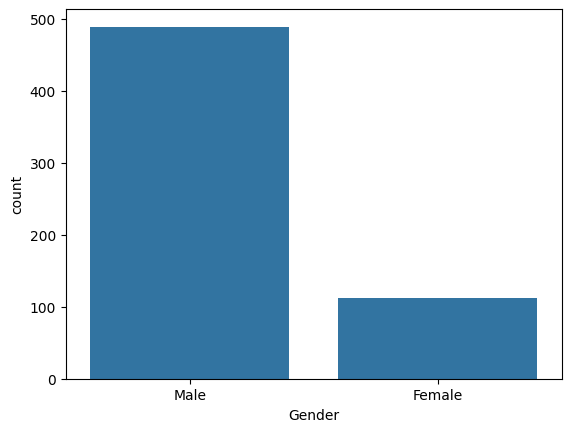

Gender
Male      489
Female    112
Name: count, dtype: int64


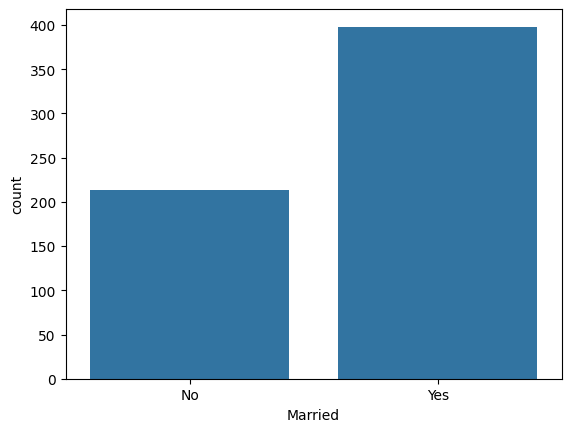

Married
Yes    398
No     213
Name: count, dtype: int64


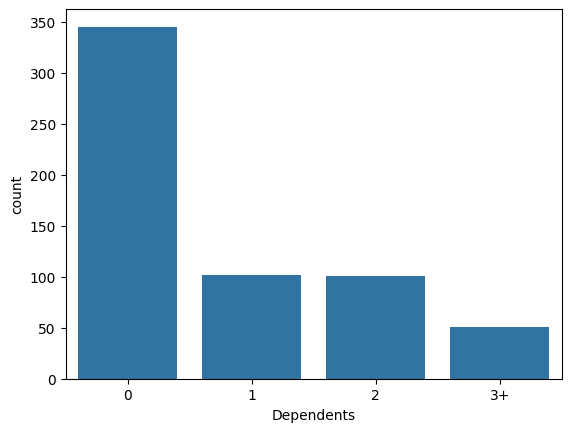

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64


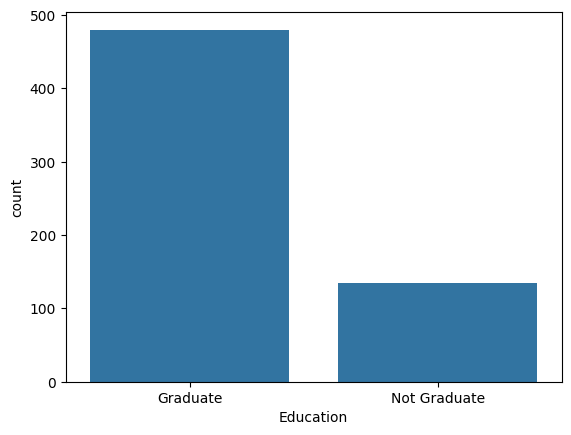

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64


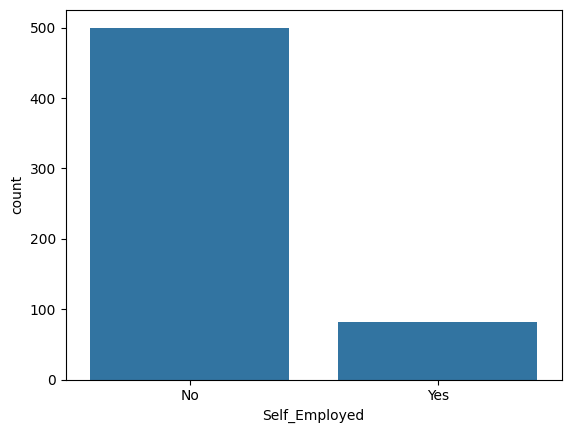

Self_Employed
No     500
Yes     82
Name: count, dtype: int64


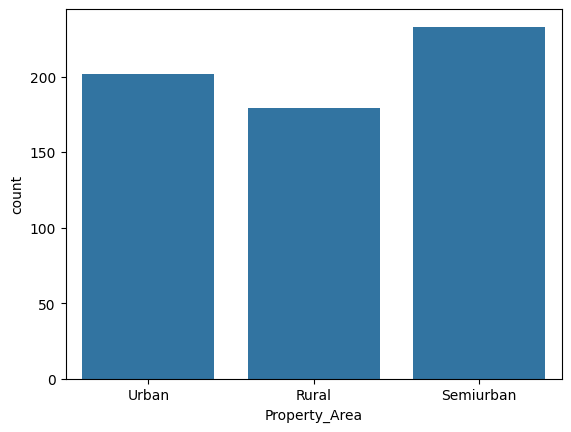

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64


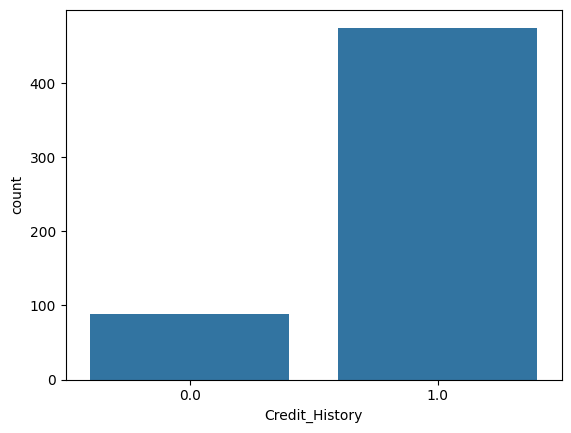

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64


In [ ]:
# Categorical columns
cat_cols = ['Gender','Married','Dependents','Education',
            'Self_Employed','Property_Area','Credit_History']

# Plot count graphs
for col in cat_cols:
    sns.countplot(x=col, data=df)
    plt.show()
    print(df[col].value_counts())

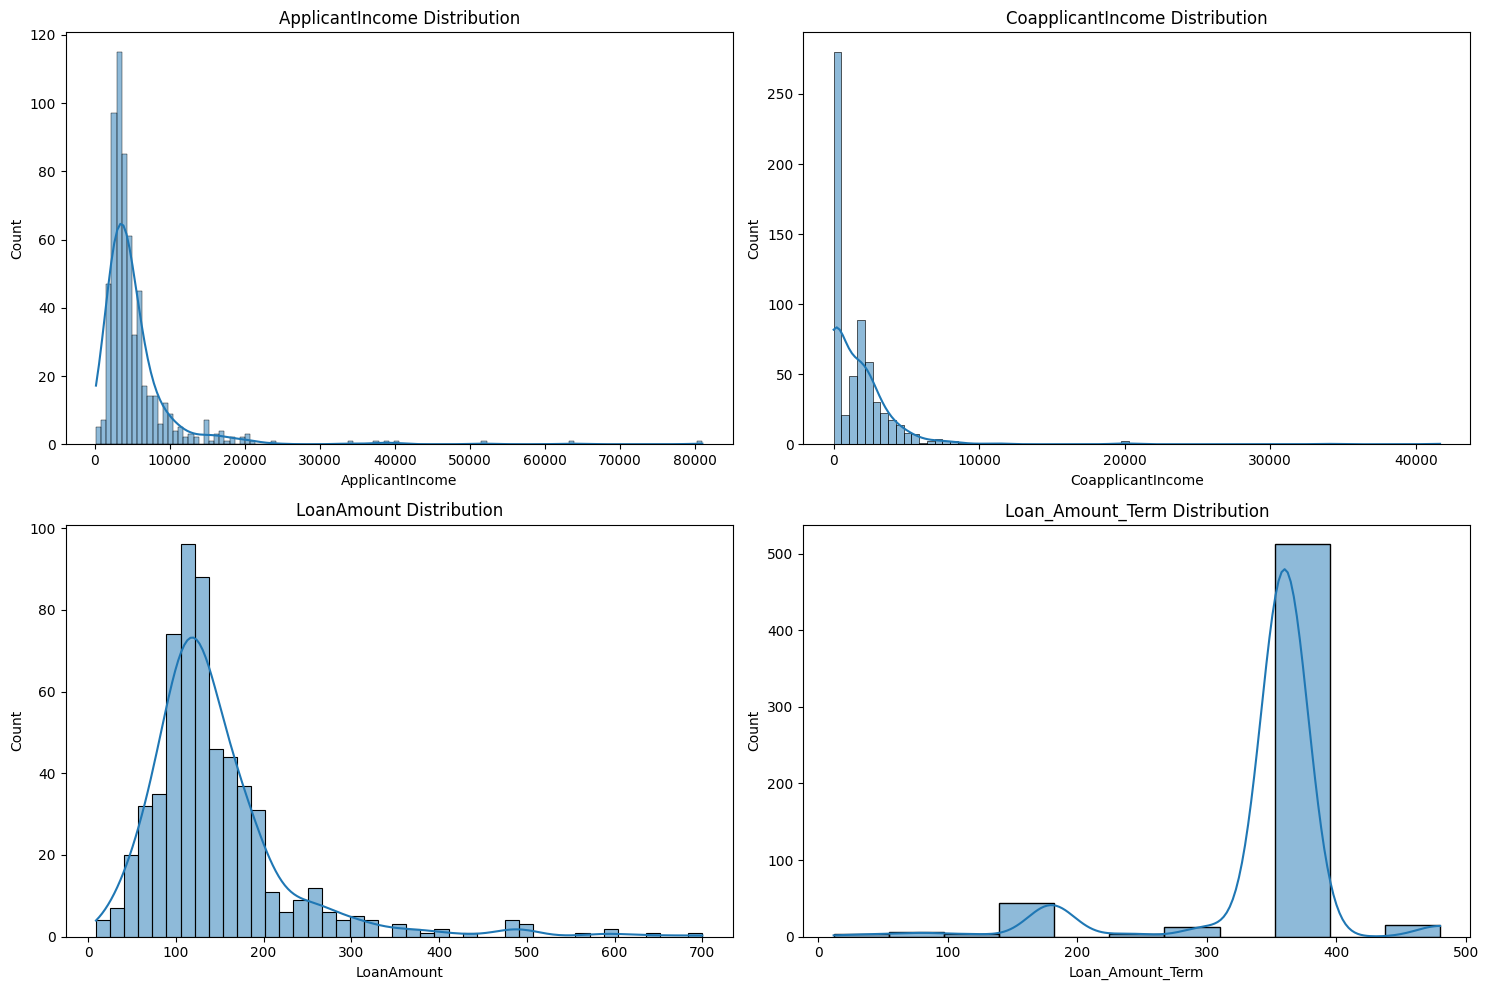

In [ ]:
# Numerical columns
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

import matplotlib.pyplot as plt
import seaborn as sns

# Plot distributions
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2,2,i)
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} Distribution')

plt.tight_layout()
plt.show()


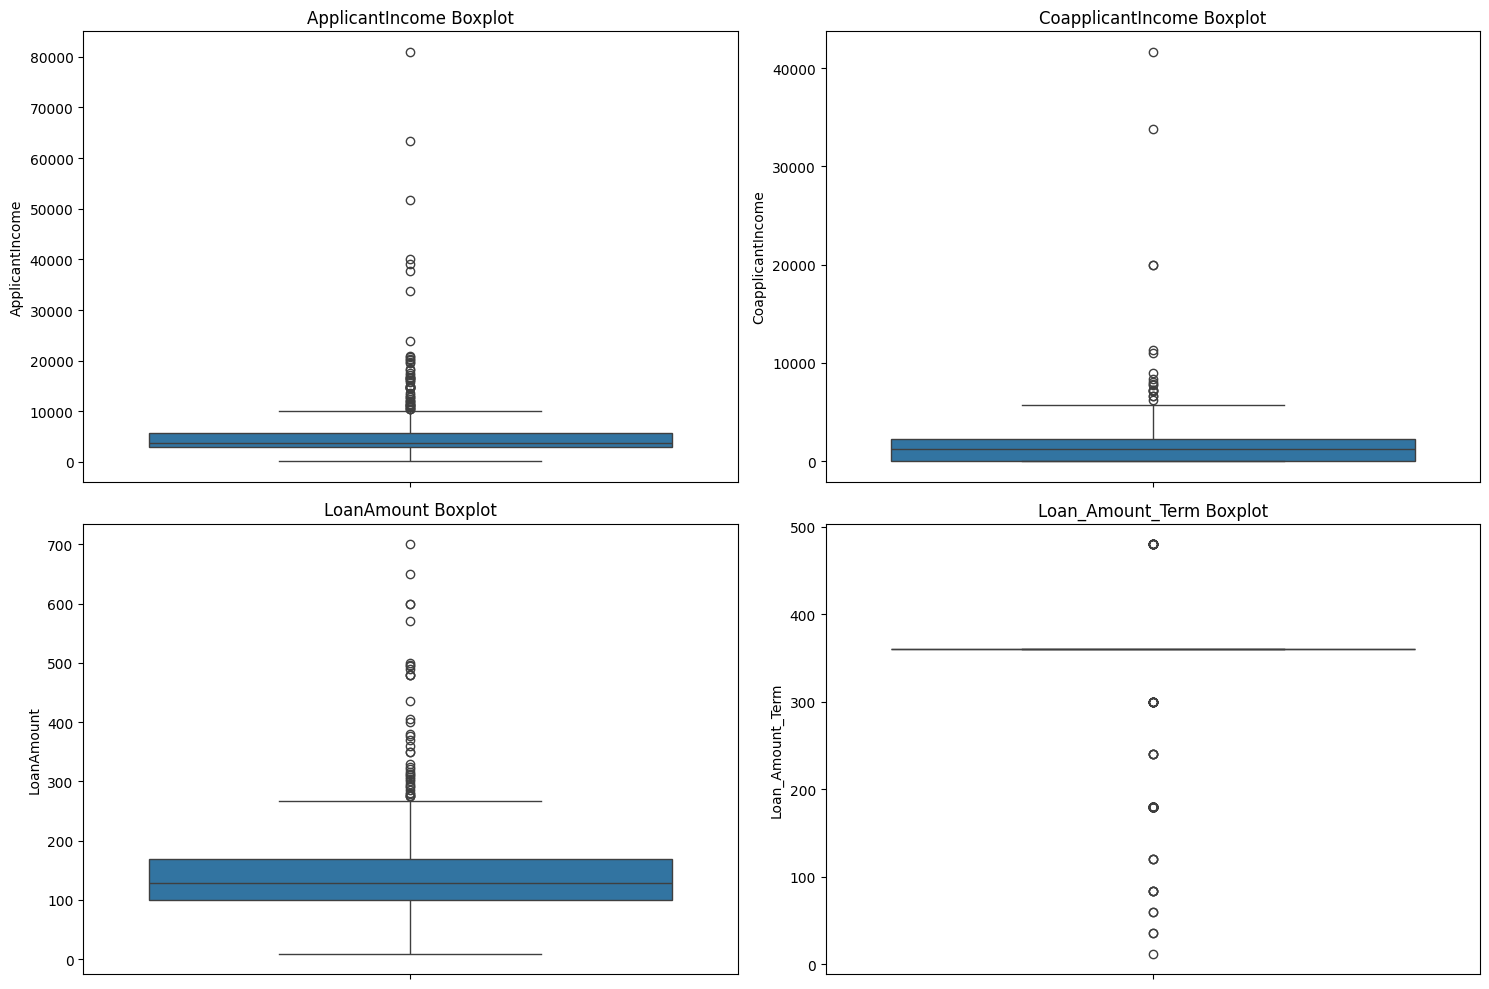

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

# Plot boxplots
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2,2,i)
    sns.boxplot(y=df[col])

    plt.title(f'{col} Boxplot')

plt.tight_layout()
plt.show()


# Bivariate Analysis



In [ ]:
# apply log transformation to reduce skewness
# -------------------------------
# Block 2: Log-transform skewed numerical features
# -------------------------------
# Features with high skewness
skewed_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

# Apply log transformation
for col in skewed_features:
    df[col+'_log'] = np.log(df[col] + 1)

# Check new skewness
df[[f+'_log' for f in skewed_features]].skew()


,0
ApplicantIncome_log,0.482128
CoapplicantIncome_log,-0.173073
LoanAmount_log,-0.150257


In [ ]:
# High-impact categorical features
categorical_features = ['Credit_History', 'Married', 'Education', 'Property_Area']

for col in categorical_features:
    approval_pct = df.groupby(col)['Loan_Status'].value_counts(normalize=True).unstack()['Y'] * 100
    print(f"\nApproval % by {col}:\n", approval_pct)



Approval % by Credit_History:
 Credit_History
0.0     7.865169
1.0    79.578947
Name: Y, dtype: float64

Approval % by Married:
 Married
No     62.910798
Yes    71.608040
Name: Y, dtype: float64

Approval % by Education:
 Education
Graduate        70.833333
Not Graduate    61.194030
Name: Y, dtype: float64

Approval % by Property_Area:
 Property_Area
Rural        61.452514
Semiurban    76.824034
Urban        65.841584
Name: Y, dtype: float64


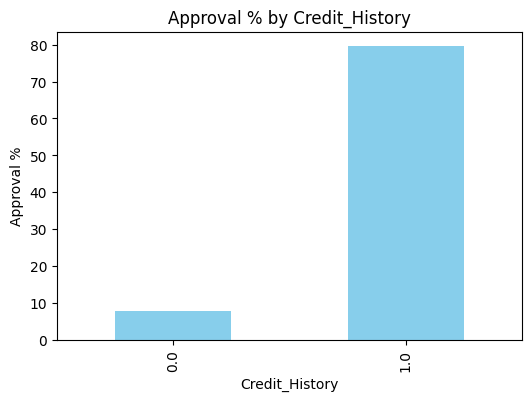

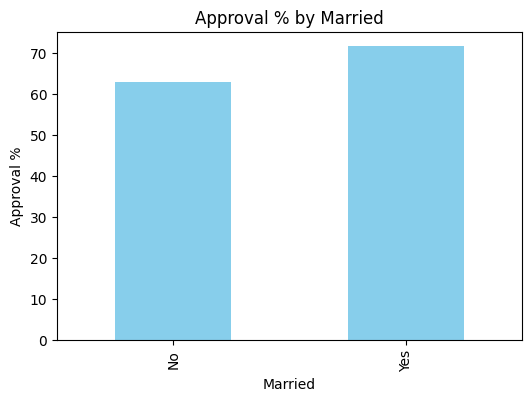

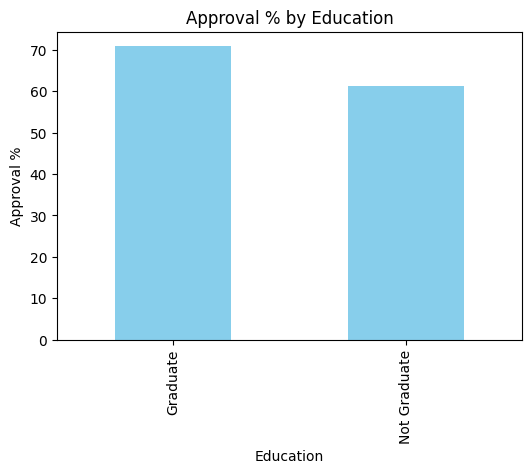

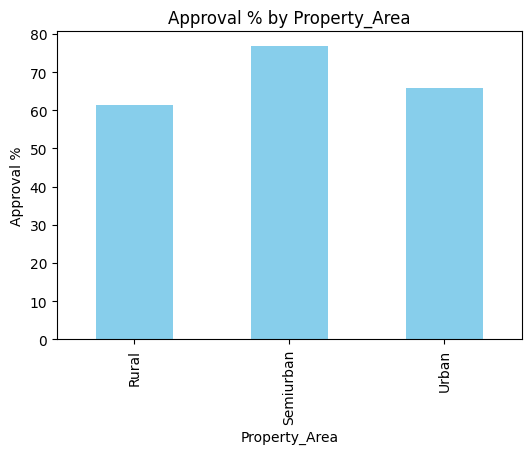

In [ ]:
import matplotlib.pyplot as plt

for col in categorical_features:
    approval_pct = df.groupby(col)['Loan_Status'].value_counts(normalize=True).unstack()['Y'] * 100
    approval_pct.plot(kind='bar', figsize=(6,4), color='skyblue')
    plt.ylabel('Approval %')
    plt.title(f'Approval % by {col}')
    plt.show()


In [ ]:
# Median of log-transformed numerical features by Loan_Status
num_features = ['ApplicantIncome_log', 'CoapplicantIncome_log', 'LoanAmount_log']
df.groupby('Loan_Status')[num_features].median()


,ApplicantIncome_log,CoapplicantIncome_log,LoanAmount_log
Loan_Status,,,
N,8.251756,3.142999,4.867534
Y,8.246303,7.123234,4.844187


## Handling Missing Values

In [ ]:
# Fill missing values in categorical columns with mode
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['LoanAmount_log'] = df['LoanAmount_log'].fillna(df['LoanAmount_log'].median())

In [ ]:
df.isnull().sum()


,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


# Feature Encoding

In [ ]:
# Select categorical columns
cat_cols = df.select_dtypes(include='object').columns

# Display column names
print(cat_cols)


Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode target column
le = LabelEncoder()
df['Loan_Status'] = le.fit_transform(df['Loan_Status'])

# Y → 1 , N → 0


In [ ]:
# Encode binary categorical columns
binary_cols = ['Gender', 'Married', 'Education', 'Self_Employed']

for col in binary_cols:
    df[col] = le.fit_transform(df[col])


In [ ]:
# Create dummy variables
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)



In [ ]:
# Convert Dependents column to integer
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  614 non-null    object 
 1   Gender                   614 non-null    int64  
 2   Married                  614 non-null    int64  
 3   Dependents               614 non-null    int64  
 4   Education                614 non-null    int64  
 5   Self_Employed            614 non-null    int64  
 6   ApplicantIncome          614 non-null    int64  
 7   CoapplicantIncome        614 non-null    float64
 8   LoanAmount               614 non-null    float64
 9   Loan_Amount_Term         614 non-null    float64
 10  Credit_History           614 non-null    float64
 11  Loan_Status              614 non-null    int64  
 12  ApplicantIncome_log      614 non-null    float64
 13  CoapplicantIncome_log    614 non-null    float64
 14  LoanAmount_log           6

In [ ]:
df.drop('Loan_ID', axis=1, inplace=True)



In [ ]:
bool_cols = ['Property_Area_Semiurban','Property_Area_Urban']
df[bool_cols] = df[bool_cols].astype(int)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   614 non-null    int64  
 1   Married                  614 non-null    int64  
 2   Dependents               614 non-null    int64  
 3   Education                614 non-null    int64  
 4   Self_Employed            614 non-null    int64  
 5   ApplicantIncome          614 non-null    int64  
 6   CoapplicantIncome        614 non-null    float64
 7   LoanAmount               614 non-null    float64
 8   Loan_Amount_Term         614 non-null    float64
 9   Credit_History           614 non-null    float64
 10  Loan_Status              614 non-null    int64  
 11  ApplicantIncome_log      614 non-null    float64
 12  CoapplicantIncome_log    614 non-null    float64
 13  LoanAmount_log           614 non-null    float64
 14  Property_Area_Semiurban  6

# Decision Tree Model

In [ ]:
# Split features and target
x = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree model
dec = DecisionTreeClassifier(max_depth=5)
dec.fit(x_train, y_train)

# Predict test data
y_pred = dec.predict(x_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Model evaluation
accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
print(cm)

print(classification_report(y_test, y_pred))

# Training accuracy
train_pred = dec.predict(x_train)
train_accuracy = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_accuracy)

# Testing accuracy
test_pred = dec.predict(x_test)
test_accuracy = accuracy_score(y_test, test_pred)

print("Testing Accuracy:", test_accuracy)

[[18 25]
 [ 5 75]]
              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123

Training Accuracy: 0.8370672097759674
Testing Accuracy: 0.7560975609756098


In [ ]:
train_pred =dec.predict(x_train)
train_accuracy = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_accuracy)


Training Accuracy: 0.8370672097759674


In [ ]:
test_pred = dec.predict(x_test)
test_accuracy = accuracy_score(y_test, test_pred)

print("Testing Accuracy:", test_accuracy)


Testing Accuracy: 0.7560975609756098


### Random Forest Model with Hyperparameter Tuning

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 9, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Apply GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1
)

# Train model
grid_search.fit(x_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Best model
best_rf = grid_search.best_estimator_

# Predict test data
y_pred_best = best_rf.predict(x_test)

# Model evaluation
accuracy = accuracy_score(y_test, y_pred_best)
cm = confusion_matrix(y_test, y_pred_best)
report = classification_report(y_test, y_pred_best)

print("Test Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.8125541125541125
Test Accuracy: 0.7886178861788617
Confusion Matrix:
 [[18 25]
 [ 1 79]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [ ]:
train_pred = best_rf.predict(x_train)
train_accuracy = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_accuracy)


Training Accuracy: 0.8207739307535642


In [ ]:
test_pred = best_rf.predict(x_test)
test_accuracy = accuracy_score(y_test, test_pred)

print("Testing Accuracy:", test_accuracy)


Testing Accuracy: 0.7886178861788617


# Streamlit code

In [2]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 71.4 MB/s eta 0:00:00


In [8]:
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# -------------------------------
# Page Configuration
# -------------------------------
st.set_page_config(
    page_title="Loan Approval Prediction",
    layout="centered"
)

# -------------------------------
# Title
# -------------------------------
st.title("Loan Approval Prediction System")
st.write("Using Decision Tree and Random Forest Algorithms")

# -------------------------------
# Load Dataset
# -------------------------------
df = pd.read_csv("loan-prediction-dataset.csv")

# -------------------------------
# Handle Missing Values
# -------------------------------
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in ['LoanAmount', 'Loan_Amount_Term']:
    df[col] = df[col].fillna(df[col].median())

# Replace 3+ in Dependents
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].astype(int)

# -------------------------------
# Label Encoding
# -------------------------------
label_cols = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Loan_Status'
]

le = LabelEncoder()

for col in label_cols:
    df[col] = le.fit_transform(df[col])

# One Hot Encoding for Property Area
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

# Convert Credit History
df['Credit_History'] = df['Credit_History'].astype(int)

# Drop Loan_ID if exists
if 'Loan_ID' in df.columns:
    df.drop('Loan_ID', axis=1, inplace=True)

# -------------------------------
# Features and Target
# -------------------------------
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# -------------------------------
# Train Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -------------------------------
# Decision Tree Model
# -------------------------------
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# -------------------------------
# Random Forest Model
# -------------------------------
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

# -------------------------------
# Accuracy Scores
# -------------------------------
dt_accuracy = accuracy_score(
    y_test,
    dt_model.predict(X_test)
)

rf_accuracy = accuracy_score(
    y_test,
    rf_model.predict(X_test)
)

# -------------------------------
# Show Accuracy
# -------------------------------
st.subheader("Model Accuracy")

st.write(f"Decision Tree Accuracy: {dt_accuracy:.2f}")
st.write(f"Random Forest Accuracy: {rf_accuracy:.2f}")

# -------------------------------
# User Input Section
# -------------------------------
st.subheader("Enter Applicant Details")

gender = st.selectbox(
    "Gender",
    ["Male", "Female"]
)

married = st.selectbox(
    "Married",
    ["Yes", "No"]
)

dependents = st.selectbox(
    "Dependents",
    [0, 1, 2, 3]
)

education = st.selectbox(
    "Education",
    ["Graduate", "Not Graduate"]
)

self_employed = st.selectbox(
    "Self Employed",
    ["Yes", "No"]
)

applicant_income = st.number_input(
    "Applicant Income",
    min_value=0
)

coapplicant_income = st.number_input(
    "Coapplicant Income",
    min_value=0
)

loan_amount = st.number_input(
    "Loan Amount",
    min_value=0
)

loan_amount_term = st.number_input(
    "Loan Amount Term",
    min_value=0
)

credit_history = st.selectbox(
    "Credit History",
    [1, 0]
)

property_area = st.selectbox(
    "Property Area",
    ["Rural", "Semiurban", "Urban"]
)

# -------------------------------
# Encode User Input
# -------------------------------
gender = 1 if gender == "Male" else 0
married = 1 if married == "Yes" else 0
education = 0 if education == "Graduate" else 1
self_employed = 1 if self_employed == "Yes" else 0

property_area_semiurban = 1 if property_area == "Semiurban" else 0
property_area_urban = 1 if property_area == "Urban" else 0

# -------------------------------
# Create Input DataFrame
# -------------------------------
input_data = pd.DataFrame({
    'Gender': [gender],
    'Married': [married],
    'Dependents': [dependents],
    'Education': [education],
    'Self_Employed': [self_employed],
    'ApplicantIncome': [applicant_income],
    'CoapplicantIncome': [coapplicant_income],
    'LoanAmount': [loan_amount],
    'Loan_Amount_Term': [loan_amount_term],
    'Credit_History': [credit_history],
    'Property_Area_Semiurban': [property_area_semiurban],
    'Property_Area_Urban': [property_area_urban]
})

# -------------------------------
# Model Selection
# -------------------------------
model_choice = st.radio(
    "Choose Model",
    ["Decision Tree", "Random Forest"]
)

# -------------------------------
# Prediction
# -------------------------------
if st.button("Predict Loan Approval"):

    if model_choice == "Decision Tree":
        prediction = dt_model.predict(input_data)

    else:
        prediction = rf_model.predict(input_data)

    if prediction[0] == 1:
        st.success("Loan Approved")
    else:
        st.error("Loan Rejected")

# -------------------------------
# Dataset Preview
# -------------------------------
st.subheader("Dataset Preview")
st.dataframe(df.head())

2026-05-08 13:15:58.789 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 13:15:58.792 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 13:15:58.793 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 13:15:58.794 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 13:15:58.795 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 13:15:58.796 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 13:15:58.798 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 13:15:59.014 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

# Conclusion

- Decision Tree and Random Forest models were used for loan approval prediction.
- Random Forest with hyperparameter tuning achieved better performance with 79% test accuracy.
- The confusion matrix shows the model correctly identified most approved loan applications with high recall.
- Data preprocessing, feature encoding, and parameter tuning improved overall model performance and reduced prediction errors.